# R-TPOJのvis-featureへの相関 or 相対誤差と確率の関係 
各被験者における予測精度の良しあしでは、gaze shiftの個人差は説明できない
→この領域だけがあればいいわけではなく、領域間のcoordinationが必要


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from voluntary_fixation.envs import TR, RUN_IDS, SUBJECT_IDS, SAVE_ROOT, NUM_ROIS, BRIGHTNESS_DIR, RUN_VOLUMES, MOVIE_FPS
import os
from sklearn.linear_model import LinearRegression
from pingouin import partial_corr
SAVE_ROOT = '../' + SAVE_ROOT

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます

In [2]:
def get_correlation_value(modality, slice_, delay):
    print(SAVE_ROOT)
    csv_dir = os.path.join('../', SAVE_ROOT, 'bold2feat_control2_strict_ree2', 'eval_specificpublic', '-remove_brightness-remove_empty_eyetrack0.5_0.7')
    print('csv_dir loaded from : ', csv_dir)
    raw_corr_filename = f'raw_value-delay{delay}' +f'-{modality}-by-{modality}-layer{"_".join(["1","10","20","30","40"][slice_])}.csv'
    raw_corr_df = pd.read_csv(os.path.join(csv_dir, raw_corr_filename))
    print('csv loaded from : ', raw_corr_filename)
    # raw_corr_df = pd.read_csv(raw_corr_filename)

    return raw_corr_df

# regression
def regression(x, y):
    reg = LinearRegression().fit(x, y)
    return reg.coef_[0], reg.intercept_[0]

In [3]:
delay = -1# [-3, -2, -1, 0, 1, 2, 3, 4, 5]
slice_ = slice(4,5,1)
remove_brightness = True
remove_empty_eyetrack = True
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'

control_modalities = ['masked_image'] # , 'shuffled_masked_image2', 'reverse_masked_image', 'whole_image', 'saliency_masked_image'] # ['masked_image', 'shift_reverse_masked_image']
for modality in control_modalities:
    print(modality)
    raw_corr_df = get_correlation_value(modality, slice_, delay)

print(raw_corr_df.query('roi==36').mean())
raw_corr_df.query('roi==36')
iou_q = 0.5
saliency_TR_q = 0.7
raw_corr_no_sal = raw_corr_df.query('roi==36')['wo_sal_corr'].values
raw_corr_with_sal = raw_corr_df.query('roi==36')['w_sal_corr'].values

# testデータにおける, gaze_shiftとsaliency_shiftの共起回数や、それぞれの発生回数
behavior_path = os.path.join('../', SAVE_ROOT, 'behavior','behaviors20251029.csv')
behavior_df = pd.read_csv(behavior_path)
target_df = behavior_df.query(f'iou_q=={iou_q} and saliency_TR_q=={saliency_TR_q}')

total = np.array([int(i) for i in target_df['total'].item().replace('[','').replace(']','').replace(',', '').split(' ')])

sal = np.array([int(i) for i in target_df['sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
not_sal = np.array([int(i) for i in target_df['not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')]) #
eye = np.array([int(i) for i in target_df['eye'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_sal = np.array([int(i) for i in target_df['joint_eye_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
joint_eye_not_sal = np.array([int(i) for i in target_df['joint_eye_not_sal'].item().replace('[','').replace(']','').replace(',', '').split(' ')])
prob_eye = eye/total
prob_inv_eye = joint_eye_sal/sal
prob_vol_eye = joint_eye_not_sal/not_sal
prob_sal = sal/total

print('CorrelationScore (raw_corr_no_sal): ', raw_corr_no_sal)
print('Probability of Gaze Shift:', np.array(prob_eye))
print('Probability of Saliency Shift:', np.array(prob_sal))
print('Probability of Gaze Shift with Saliency Shift:', np.array(prob_inv_eye))
print('Probability of Gaze Shift without Saliency Shift:', np.array(prob_vol_eye))

prob_voluntary = np.array(prob_vol_eye)
prob_involuntary = np.array(prob_inv_eye)
prob_eye = np.array(prob_eye)

masked_image
../../../results/voluntary_fixation
csv_dir loaded from :  ../../../../results/voluntary_fixation/bold2feat_control2_strict_ree2/eval_specificpublic/-remove_brightness-remove_empty_eyetrack0.5_0.7
csv loaded from :  raw_value-delay-1-masked_image-by-masked_image-layer40.csv
Unnamed: 0     278.000000
sbj             10.416667
roi             36.000000
w_sal_corr       0.048799
wo_sal_corr      0.104054
dtype: float64
CorrelationScore (raw_corr_no_sal):  [ 0.06740205 -0.00419399  0.13848053  0.09873754  0.17271781  0.15117677
  0.07743709  0.08636545  0.11701792  0.15884878  0.04813327  0.13652049]
Probability of Gaze Shift: [0.5031211  0.49299363 0.50636132 0.47399703 0.46134663 0.41304348
 0.47588832 0.43246592 0.46787709 0.52970297 0.51823899 0.4487021 ]
Probability of Saliency Shift: [0.34082397 0.34904459 0.34605598 0.32986627 0.34413965 0.342711
 0.34390863 0.34076828 0.33379888 0.34158416 0.34465409 0.33868974]
Probability of Gaze Shift with Saliency Shift: [0.5604395

/home/kazu/shared_response/figures/fig5/RTPOJ_correlation_vs_prob_eye_voluntary.pdf
/home/kazu/shared_response/figures/fig5/RTPOJ_correlation_vs_prob_eye_involuntary.pdf


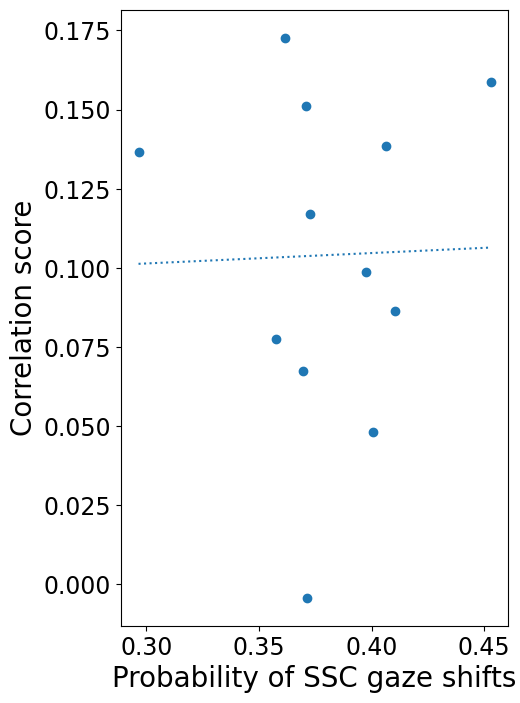

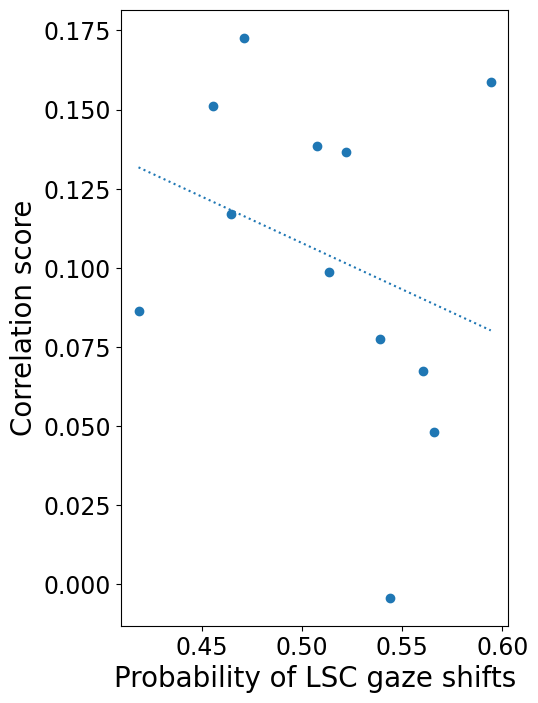

In [4]:
# fig = plt.figure(figsize=(10,8))
fig = plt.figure(figsize=(5,8))
plt.scatter(prob_voluntary, raw_corr_no_sal, label='small saliency change')
a, b = regression(prob_voluntary[:,np.newaxis], raw_corr_no_sal[:,np.newaxis])
plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')

# plt.scatter(prob_voluntary, raw_corr_with_sal, label='large saliency change')
# a, b = regression(prob_voluntary[:,np.newaxis], raw_corr_with_sal[:,np.newaxis])
# plt.plot([prob_voluntary.min(), prob_voluntary.max()], [a*prob_voluntary.min()+b, a*prob_voluntary.max()+b], ':')



plt.xlabel('Probability of SSC gaze shifts')
# plt.ylabel('Correlation coefficient \nbetween R-TPOJ and masked image feature')
plt.ylabel('Correlation score')
# plt.legend(fontsize=15)
# plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left', borderaxespad=0, fontsize=15)
# plt.show()
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig5', 'RTPOJ_correlation_vs_prob_eye_voluntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

fig = plt.figure(figsize=(5,8))
plt.scatter(prob_involuntary, raw_corr_no_sal, label='small saliency change')
a, b = regression(prob_involuntary[:,np.newaxis], raw_corr_no_sal[:,np.newaxis])
plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')

# plt.scatter(prob_involuntary, raw_corr_with_sal, label='large saliency change')
# a, b = regression(prob_involuntary[:,np.newaxis], raw_corr_with_sal[:,np.newaxis])
# plt.plot([prob_involuntary.min(), prob_involuntary.max()], [a*prob_involuntary.min()+b, a*prob_involuntary.max()+b], ':')



plt.xlabel('Probability of LSC gaze shifts')
plt.ylabel('Correlation score')
# plt.legend(fontsize=15)
# plt.legend(bbox_to_anchor=(0, -0.15), loc='upper left', borderaxespad=0, fontsize=15)
# plt.show()
savepath =os.path.join('/home/kazu/shared_response/figures', 'fig5', 'RTPOJ_correlation_vs_prob_eye_involuntary.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)



def compute_corr(explain_val, behavior, control_behavior, ret):
    shuffle_times = 1000
    num_seeds = 10
    ## spearman corr
    df = pd.DataFrame({'fc': explain_val, 'target': behavior})
    test_corr = partial_corr(df, x='fc', y='target')['r'].item()
    ret['corr'].append(test_corr)

    sbj_indices = np.arange(len(SUBJECT_IDS))
    corr_ranks = []
    for seed in range(num_seeds):
        np.random.seed(seed)
        shuffled_test_corrs = []
        for _ in range(shuffle_times):
            shuffle_sbj_indices = np.random.permutation(sbj_indices)
            shuffled_behavior = behavior[shuffle_sbj_indices]
            df = pd.DataFrame({'fc': explain_val, 'shuffled_target': shuffled_behavior})
            shuffled_test_corr = partial_corr(df, x='fc', y='shuffled_target')['r'].item()
            shuffled_test_corrs.append(shuffled_test_corr)
        print(ret)
        corrs = [test_corr] + shuffled_test_corrs
        corrs_arr = np.array(corrs)
        sorted_corrs = np.sort(corrs_arr)[::-1] # descending order
        corr_rank = np.where(sorted_corrs==test_corr)[0][0]
        corr_ranks.append(corr_rank)

    ret['corr_rank'].append(np.mean(corr_ranks))

    ## partial corr
    control_behavior = prob_eye
    df = pd.DataFrame({'fc': explain_val, 'target': behavior, 'control': control_behavior})
    test_par_corr = partial_corr(df, x='fc', y='target', covar='control')['r'].item()
    ret['par_corr'].append(test_par_corr)
    sbj_indices = np.arange(len(SUBJECT_IDS))
    corr_ranks = []
    for seed in range(num_seeds):
        np.random.seed(seed)
        shuffled_test_corrs = []
        for _ in range(shuffle_times):
            shuffle_sbj_indices = np.random.permutation(sbj_indices)
            shuffled_target_behavior = behavior[shuffle_sbj_indices]
            shuffled_control_behavior = control_behavior[shuffle_sbj_indices]
            df = pd.DataFrame({'fc': explain_val, 'shuffled_target': shuffled_target_behavior,
            'shuffled_control': shuffled_control_behavior})
            shuffled_test_corr = partial_corr(df, x='fc', y='shuffled_target', covar='shuffled_control')['r'].item()
            shuffled_test_corrs.append(shuffled_test_corr)
        corrs = [test_par_corr] + shuffled_test_corrs
        corrs_arr = np.array(corrs)
        sorted_corrs = np.sort(corrs_arr)[::-1] # descending order
        corr_rank = np.where(sorted_corrs==test_par_corr)[0][0]
        corr_ranks.append(corr_rank)
    print(ret)
    ret['par_corr_rank'].append(np.mean(corr_ranks))
    return ret

# ret = {
#     'target':[],
#     'explain': [],
#     'corr':[],
#     'par_corr':[],
#     'corr_rank': [],
#     'par_corr_rank': []
# }
# shuffle_times = 1000
# # corr bwtween prob_voluntary and correlation
# behavior = prob_voluntary
# ## vs raw_corr_no_sal
# explain_val = raw_corr_no_sal
# ret['target'].append('prob_voluntary')
# ret['explain'].append('raw_corr_no_sal')
# ret = compute_corr(explain_val, behavior, prob_eye, ret)

# ## vs raw_corr_with_sal
# explain_val = raw_corr_with_sal
# ret['target'].append('prob_voluntary')
# ret['explain'].append('raw_corr_with_sal')
# ret = compute_corr(explain_val, behavior, prob_eye, ret)

# # corr bwtween prob_involuntary and correlation
# behavior = prob_involuntary
# ## vs raw_corr_no_sal
# explain_val = raw_corr_no_sal
# ret['target'].append('prob_involuntary')
# ret['explain'].append('raw_corr_no_sal')
# ret = compute_corr(explain_val, behavior, prob_eye, ret)
# ## vs raw_corr_with_sal
# explain_val = raw_corr_with_sal
# ret['target'].append('prob_involuntary')
# ret['explain'].append('raw_corr_with_sal')
# ret = compute_corr(explain_val, behavior, prob_eye, ret)

# ret_df = pd.DataFrame(ret)
# ret_df





In [5]:

ret = {
    'target':[],
    'explain': [],
    'corr':[],
    'par_corr':[],
    'corr_rank': [],
    'par_corr_rank': []
}
shuffle_times=1000
behavior = prob_voluntary
## vs raw_corr_no_sal
explain_val = raw_corr_no_sal
ret['target'].append('prob_voluntary')
ret['explain'].append('raw_corr_no_sal')

## spearman corr
df = pd.DataFrame({'fc': explain_val, 'target': behavior})
test_corr = partial_corr(df, x='fc', y='target')['r'].item()
ret['corr'].append(test_corr)
sbj_indices = np.arange(len(SUBJECT_IDS))
corr_ranks = []
for _ in range(10):
    shuffled_test_corrs = []
    for _ in range(shuffle_times):
        shuffle_sbj_indices = np.random.permutation(sbj_indices)
        shuffled_behavior = behavior[shuffle_sbj_indices]
        df = pd.DataFrame({'fc': explain_val, 'shuffled_target': shuffled_behavior})
        shuffled_test_corr = partial_corr(df, x='fc', y='shuffled_target')['r'].item()
        shuffled_test_corrs.append(shuffled_test_corr)
    # print(ret)
    corrs = [test_corr] + shuffled_test_corrs
    corrs_arr = np.array(corrs)
    sorted_corrs = np.sort(corrs_arr)[::-1] # descending order
    corr_rank = np.where(sorted_corrs==test_corr)[0][0]
    corr_ranks.append(corr_rank)
ret['corr_rank'].append(np.mean(corr_rank))

## partial corr
control_behavior = prob_eye
df = pd.DataFrame({'fc': explain_val, 'target': behavior, 'control': control_behavior})
test_par_corr = partial_corr(df, x='fc', y='target', covar='control')['r'].item()
ret['par_corr'].append(test_par_corr)
sbj_indices = np.arange(len(SUBJECT_IDS))
corr_ranks = []
for _ in range(10):
    shuffled_test_corrs = []
    for _ in range(shuffle_times):
        shuffle_sbj_indices = np.random.permutation(sbj_indices)
        shuffled_target_behavior = behavior[shuffle_sbj_indices]
        shuffled_control_behavior = control_behavior[shuffle_sbj_indices]
        df = pd.DataFrame({'fc': explain_val, 'shuffled_target': shuffled_target_behavior,
        'shuffled_control': shuffled_control_behavior})
        shuffled_test_corr = partial_corr(df, x='fc', y='shuffled_target', covar='shuffled_control')['r'].item()
        shuffled_test_corrs.append(shuffled_test_corr)
    corrs = [test_par_corr] + shuffled_test_corrs
    corrs_arr = np.array(corrs)
    sorted_corrs = np.sort(corrs_arr)[::-1] # descending order
    corr_rank = np.where(sorted_corrs==test_par_corr)[0][0]
    corr_ranks.append(corr_rank)
ret['par_corr_rank'].append(np.mean(corr_ranks))
print(ret)
ret_df = pd.DataFrame(ret)
ret_df

{'target': ['prob_voluntary'], 'explain': ['raw_corr_no_sal'], 'corr': [0.024041303358719773], 'par_corr': [0.18124839104805654], 'corr_rank': [450.0], 'par_corr_rank': [298.2]}


,target,explain,corr,par_corr,corr_rank,par_corr_rank
0,prob_voluntary,raw_corr_no_sal,0.024041,0.181248,450.0,298.2


In [17]:

ret = {
    'target':[],
    'explain': [],
    'corr':[],
    'par_corr':[],
    'corr_rank': [],
    'par_corr_rank': []
}
shuffle_times=1000
behavior = prob_involuntary
## vs raw_corr_no_sal
explain_val = raw_corr_no_sal
ret['target'].append('prob_involuntary')
ret['explain'].append('raw_corr_no_sal')

## spearman corr
df = pd.DataFrame({'fc': explain_val, 'target': behavior})
test_corr = partial_corr(df, x='fc', y='target')['r'].item()
ret['corr'].append(test_corr)
sbj_indices = np.arange(len(SUBJECT_IDS))
corr_ranks = []
for _ in range(10):
    shuffled_test_corrs = []
    for _ in range(shuffle_times):
        shuffle_sbj_indices = np.random.permutation(sbj_indices)
        shuffled_behavior = behavior[shuffle_sbj_indices]
        df = pd.DataFrame({'fc': explain_val, 'shuffled_target': shuffled_behavior})
        shuffled_test_corr = partial_corr(df, x='fc', y='shuffled_target')['r'].item()
        shuffled_test_corrs.append(shuffled_test_corr)
    # print(ret)
    corrs = [test_corr] + shuffled_test_corrs
    corrs_arr = np.array(corrs)
    sorted_corrs = np.sort(corrs_arr)[::-1] # descending order
    corr_rank = np.where(sorted_corrs==test_corr)[0][0]
    corr_ranks.append(corr_rank)
ret['corr_rank'].append(np.mean(corr_rank))

## partial corr
control_behavior = prob_eye
df = pd.DataFrame({'fc': explain_val, 'target': behavior, 'control': control_behavior})
test_par_corr = partial_corr(df, x='fc', y='target', covar='control')['r'].item()
ret['par_corr'].append(test_par_corr)
sbj_indices = np.arange(len(SUBJECT_IDS))
corr_ranks = []
for _ in range(10):
    shuffled_test_corrs = []
    for _ in range(shuffle_times):
        shuffle_sbj_indices = np.random.permutation(sbj_indices)
        shuffled_target_behavior = behavior[shuffle_sbj_indices]
        shuffled_control_behavior = control_behavior[shuffle_sbj_indices]
        df = pd.DataFrame({'fc': explain_val, 'shuffled_target': shuffled_target_behavior,
        'shuffled_control': shuffled_control_behavior})
        shuffled_test_corr = partial_corr(df, x='fc', y='shuffled_target', covar='shuffled_control')['r'].item()
        shuffled_test_corrs.append(shuffled_test_corr)
    corrs = [test_par_corr] + shuffled_test_corrs
    corrs_arr = np.array(corrs)
    sorted_corrs = np.sort(corrs_arr)[::-1] # descending order
    corr_rank = np.where(sorted_corrs==test_par_corr)[0][0]
    corr_ranks.append(corr_rank)
ret['par_corr_rank'].append(np.mean(corr_ranks))
print(ret)
ret_df = pd.DataFrame(ret)
ret_df

{'target': ['prob_involuntary'], 'explain': ['raw_corr_no_sal'], 'corr': [-0.29375158162313714], 'par_corr': [-0.129239031699122], 'corr_rank': [827.0], 'par_corr_rank': [651.3]}


,target,explain,corr,par_corr,corr_rank,par_corr_rank
0,prob_involuntary,raw_corr_no_sal,-0.293752,-0.129239,827.0,651.3


In [10]:

ret = {
    'target':[],
    'explain': [],
    'corr':[],
    'par_corr':[],
    'corr_rank': [],
    'par_corr_rank': []
}

behavior = prob_voluntary
## vs raw_corr_no_sal
explain_val = raw_corr_no_sal
ret['target'].append('prob_voluntary')
ret['explain'].append('raw_corr_no_sal')

## spearman corr
df = pd.DataFrame({'fc': explain_val, 'target': behavior})
test_corr = partial_corr(df, x='fc', y='target')['r'].item()
ret['corr'].append(test_corr)
shuffled_test_corrs = []
sbj_indices = np.arange(len(SUBJECT_IDS))
for _ in range(shuffle_times):
    shuffle_sbj_indices = np.random.permutation(sbj_indices)
    shuffled_behavior = behavior[shuffle_sbj_indices]
    df = pd.DataFrame({'fc': explain_val, 'shuffled_target': shuffled_behavior})
    shuffled_test_corr = partial_corr(df, x='fc', y='shuffled_target')['r'].item()
    shuffled_test_corrs.append(shuffled_test_corr)

corrs = [test_corr] + shuffled_test_corrs
corrs_arr = np.array(corrs)
sorted_corrs = np.sort(corrs_arr)[::-1] # descending order
corr_rank = np.where(sorted_corrs==test_corr)[0][0]
ret['corr_rank'].append(corr_rank)
print(ret)

{'target': ['prob_voluntary'], 'explain': ['raw_corr_no_sal'], 'corr': [0.024041303358719773], 'par_corr': [], 'corr_rank': [465], 'par_corr_rank': []}


In [92]:
shuffled_test_corrs

[]

In [96]:
np.where(sorted_corrs==test_corr)

(array([473]),)